## Семинар 5: "Улучшение сходимости нейросетей"

ФИО: Кириленко Ульяна Олеговна

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms
%matplotlib inline

## Описание задания:
Вам необходимо реализовать оставшиеся методы из лекции и сравнить их на примере из семинара.

## Задание разделено на следующие части:
1. Реализация Xavier **(1 балл)**

2.1 Реализация DropConnect **(1 балл)**

2.2 Сравнение обучения при использовании Dropout и DropConnect **(1 балл)**

3.1 Реализация LayerNorm **(2 балл)**

## Срок выполнения задания:
Данное задание можно сдать без штрафов до 8 октября.


### Часть 1: Инициализация весов

Будем использовать MNIST для обучения:

In [3]:
# Dataloader
to_numpy = lambda x: x.numpy()
transform = transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                    ])
train_dataset = MNIST('.', train=True, download=True, transform=transform)
test_dataset = MNIST('.', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)

In [4]:
images_train, labels_train = next(iter(train_loader))

In [5]:
## Usage example:
for X, y in train_loader:
    X = X.view(X.size(0), -1)
    X = X.numpy() ### Converts torch.Tensor to numpy array
    y = y.numpy()
    break

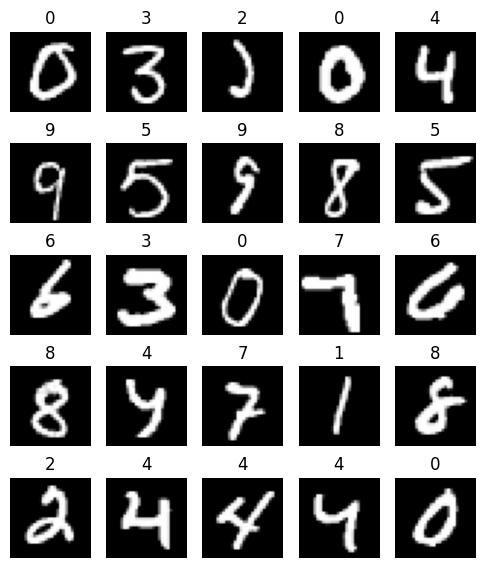

In [6]:
plt.figure(figsize=(6, 7))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.Greys_r)
    plt.title(y[i])
    plt.axis('off')

In [7]:
def init_layer(layer, mean=0, std=1):
    # Тут надо быть аккуратным — можно случайно создать копию и менять значения у копии
    weight = layer.state_dict()['weight']
    bias = layer.state_dict()['bias']
    bias.zero_()
    weight.normal_(mean=0, std=std)

def forward_hook(self, input_, output):
    std = input_[0].std().item()
    print('forward', std)

def backward_hook(self, grad_input, grad_output):
    std = grad_input[0].std().item()
    print('backward', std)

## He

In [27]:
layer_1 = nn.Linear(28*28, 256)
layer_2 = nn.Linear(256, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

init_layer(layer_1, 0, 2 / (28*28))
init_layer(layer_2, 0, 2 / 10)

In [28]:
network = nn.Sequential(
    layer_1,
    nn.ReLU(),
    layer_2
)

n_objects = 100
X = images_train[:n_objects].view(n_objects, -1).data
y = labels_train[:n_objects].data
activations = network(X)
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss = loss_fn(activations, y)
loss.backward()

forward 1.0177477598190308
forward 0.04289037361741066
backward 0.042946990579366684
backward 0.038551319390535355


На вход передаем изображение 28x28, на выходе -- вероятности 10 классов.

#### 1.1 Реализуйте инициализацию Xavier. Сравните ее с He, которая была реализована на семинаре, сделайте выводы. Учтите, что для Xavier необходимо использовать функцию активации nn.Tanh(). **(1 балл)**

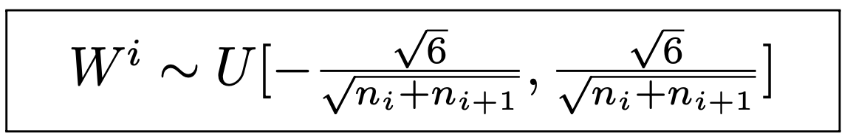

In [29]:
def init_xavier(layer):
    n_in = layer.weight.size(1) 
    n_out = layer.weight.size(0)
    
    a = np.sqrt(6.0 / (n_in + n_out + 1))
    
    nn.init.uniform_(layer.weight, -a, a)
    nn.init.zeros_(layer.bias)

In [30]:
layer_1 = nn.Linear(28*28, 256)
layer_2 = nn.Linear(256, 10)

layer_1.register_forward_hook(forward_hook)
layer_2.register_forward_hook(forward_hook)

layer_1.register_backward_hook(backward_hook)
layer_2.register_backward_hook(backward_hook)

init_xavier(layer_1)
init_xavier(layer_2)

In [31]:
network = nn.Sequential(
    layer_1,
    nn.Tanh(),
    layer_2
)


n_objects = 100
X = images_train[:n_objects].view(n_objects, -1).data
y = labels_train[:n_objects].data
activations = network(X)
loss_fn = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss = loss_fn(activations, y)
loss.backward()

forward 1.0177477598190308
forward 0.6896554231643677
backward 0.042946990579366684
backward 0.016521712765097618


результаты Не:  
forward 1.0177477598190308  
forward 0.04289037361741066  
backward 0.042946990579366684  
backward 0.038551319390535355   

У Xavier в backward меньший градиент.

## Часть 2: DropConnect

#### 2.1 Реализуйте DropConnect по следующему шаблону: **(1 балл)**

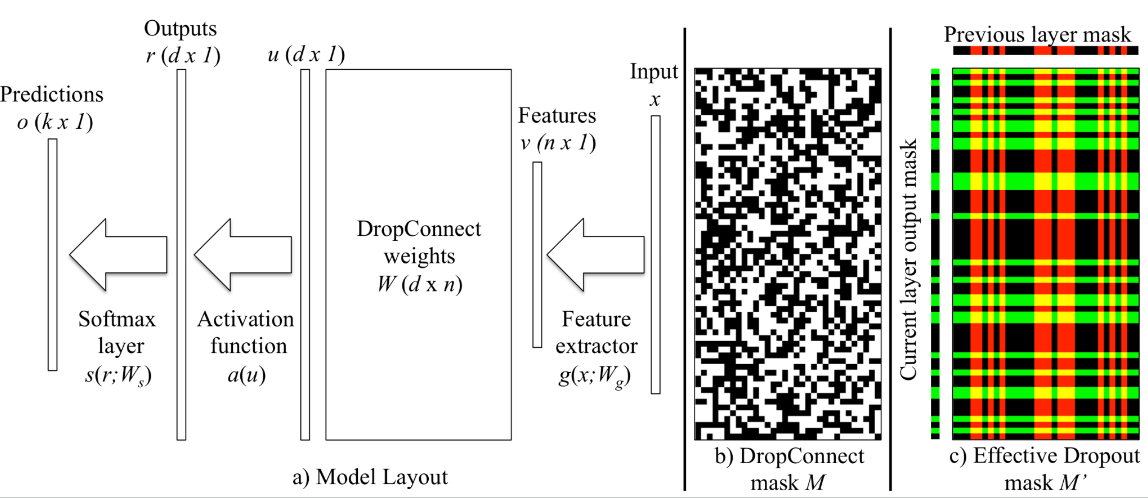

In [15]:
# полезная функция: .bernoulli_(p)
# не забывайте делать requires_grad=False у маски
# помните, что в вычислениях должны участвовать Variable, а не тензоры

class DropConnect(nn.Module):
    def __init__(self, input_dim, output_dim, p=0.5):
        super(DropConnect, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.p = p

    def forward(self, x):
        if self.training:
            mask = torch.empty_like(self.linear.weight).bernoulli_(self.p)
            mask.requires_grad = False
        else:
            mask = torch.ones_like(self.linear.weight) * self.p
            mask.requires_grad = False

        mask = mask.data
        output = F.linear(x, self.linear.weight * mask, self.linear.bias)
        return output

Основа для сети, которую будем обучать:

In [16]:
class TestNetwork(nn.Module):
    def __init__(self, final_part):
        super().__init__()

        channels = 1

        self.conv_layers = nn.Sequential(
            nn.Conv2d(channels, 2, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(2, 4, 3, padding=1),
            nn.MaxPool2d(2),
            nn.ReLU(),
        )

        #input_size = 7 * 7 * 4 = 196
        self.flatten = nn.Flatten()

        self.final_part = final_part

        self.log_softmax = nn.LogSoftmax(1)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.final_part(x)
        return self.log_softmax(x)

Добавим несколько слоев в конец сети:

In [17]:
layers = [
    DropConnect(196, 150), 
    nn.ReLU(),
    DropConnect(150, 50),
    nn.ReLU(),
    nn.Linear(50, 10) 
]

In [18]:
network = TestNetwork(nn.Sequential(*layers))
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
loss_fn = torch.nn.NLLLoss()

Обучим получившуюся сеть:

In [19]:
for epoch in range(10):
    network.train()
    for batch_idx, (images_train, labels_train) in enumerate(train_loader):
        optimizer.zero_grad()
        X = images_train.data
        y = labels_train.data
        output = network(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
            epoch, batch_idx * len(X), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()))

    network.eval()
    losses = []
    for batch_idx, (images_test, labels_test) in enumerate(test_loader):
        X = images_test.data
        y = labels_test.data
        output = network(X)
        loss = loss_fn(output, y)

        losses.append(loss.item())

    print('Test Epoch: {}\tLoss: {:.6f}'.format(
            epoch, np.mean(losses)))


Train Epoch: 0 [0/60000 (0%)]	Loss: 2.308842
Train Epoch: 0 [12800/60000 (21%)]	Loss: 1.083665
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.922026
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.558134
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.590682
Test Epoch: 0	Loss: 0.398569
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.668499
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.450090
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.376399
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.363844
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.329312
Test Epoch: 1	Loss: 0.269507
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.502187
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.516258
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.352633
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.321820
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.337083
Test Epoch: 2	Loss: 0.181545
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.172984
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.250874
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.222993
Train Epoch: 3 [38400/60000 (64%)


#### 2.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Dropout между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и DropConnect вместо всех линейных слоев


In [21]:
layers_dropout = [
    nn.Linear(196, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 10)
]

network_dropout = TestNetwork(nn.Sequential(*layers_dropout))

layers_dropconnect = [
    DropConnect(196, 128, p=0.5),
    nn.ReLU(),
    DropConnect(128, 128, p=0.5),
    nn.ReLU(),
    DropConnect(128, 10, p=0.5)
]

network_dropconnect = TestNetwork(nn.Sequential(*layers_dropconnect))

In [22]:
def train_model(network, model_name, n_epochs=10):
    optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
    loss_fn = torch.nn.NLLLoss()
    
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    
    for epoch in range(n_epochs):
        network.train()
        epoch_train_losses = []
        epoch_train_correct = 0
        epoch_train_total = 0
        
        for batch_idx, (images_train, labels_train) in enumerate(train_loader):
            optimizer.zero_grad()
            X = images_train.data
            y = labels_train.data
            output = network(X)
            loss = loss_fn(output, y)
            loss.backward()
            optimizer.step()
        
            if batch_idx % 100 == 0:
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(X), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            
            epoch_train_losses.append(loss.item())
            pred = output.argmax(dim=1)
            epoch_train_correct += (pred == y).sum().item()
            epoch_train_total += y.size(0)
        
        train_loss = np.mean(epoch_train_losses)
        train_accuracy = epoch_train_correct / epoch_train_total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        
        network.eval()
        epoch_test_losses = []
        epoch_test_correct = 0
        epoch_test_total = 0
        with torch.no_grad():
            for batch_idx, (images_test, labels_test) in enumerate(test_loader):
                X = images_test.data
                y = labels_test.data
                output = network(X)
                loss = loss_fn(output, y)
                
                epoch_test_losses.append(loss.item())
                pred = output.argmax(dim=1)
                epoch_test_correct += (pred == y).sum().item()
                epoch_test_total += y.size(0)
        
        test_loss = np.mean(epoch_test_losses)
        test_accuracy = epoch_test_correct / epoch_test_total
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)
        
        print(f'{model_name} Epoch {epoch}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}')
    
    return {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies
    }

## Обучение модели с Dropout

In [23]:
results_dropout = train_model(network_dropout, "Dropout")

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.313208
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.777787
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.634544
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.371027
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.458284
Dropout Epoch 0: Train Loss: 0.7079, Train Acc: 0.7693, Test Loss: 0.2234, Test Acc: 0.9296
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.435437
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.298246
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.284278
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.207186
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.249838
Dropout Epoch 1: Train Loss: 0.3040, Train Acc: 0.9083, Test Loss: 0.1560, Test Acc: 0.9500
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.315650
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.235733
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.227975
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.125697
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.112956
Dropout Epoch 2: Train Loss: 0.2334, Train Acc: 0.9306, Test Loss: 0.1189, Test A

## Обучение модели с DropConnect

In [24]:
results_dropconnect = train_model(network_dropconnect, "DropConnect")

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.297557
Train Epoch: 0 [12800/60000 (21%)]	Loss: 1.582168
Train Epoch: 0 [25600/60000 (43%)]	Loss: 1.009704
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.898082
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.699253
DropConnect Epoch 0: Train Loss: 1.1827, Train Acc: 0.5789, Test Loss: 0.4175, Test Acc: 0.8756
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.820010
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.634508
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.520575
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.250357
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.601313
DropConnect Epoch 1: Train Loss: 0.5186, Train Acc: 0.8268, Test Loss: 0.2680, Test Acc: 0.9165
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.413670
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.312758
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.351937
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.376215
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.385716
DropConnect Epoch 2: Train Loss: 0.3708, Train Acc: 0.8803, Test Loss: 0.

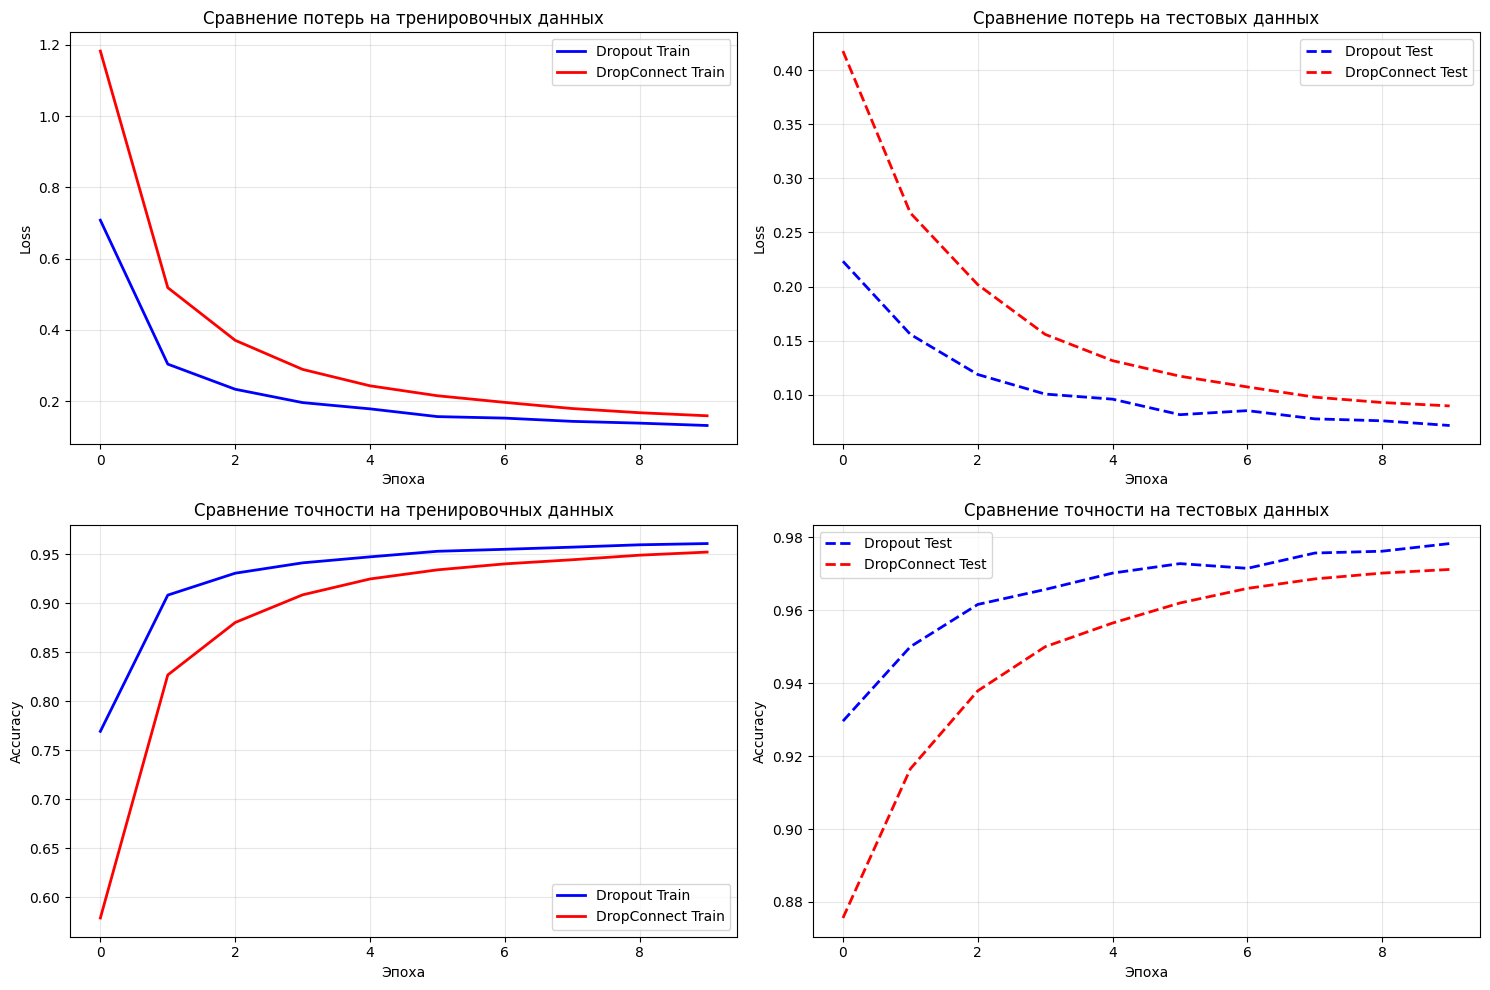

In [25]:
plt.figure(figsize=(15, 10))

# Графики потерь
plt.subplot(2, 2, 1)
plt.plot(results_dropout['train_losses'], 'b-', label='Dropout Train', linewidth=2)
plt.plot(results_dropconnect['train_losses'], 'r-', label='DropConnect Train', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сравнение потерь на тренировочных данных')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(results_dropout['test_losses'], 'b--', label='Dropout Test', linewidth=2)
plt.plot(results_dropconnect['test_losses'], 'r--', label='DropConnect Test', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сравнение потерь на тестовых данных')
plt.legend()
plt.grid(True, alpha=0.3)

# Графики точности
plt.subplot(2, 2, 3)
plt.plot(results_dropout['train_accuracies'], 'b-', label='Dropout Train', linewidth=2)
plt.plot(results_dropconnect['train_accuracies'], 'r-', label='DropConnect Train', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Сравнение точности на тренировочных данных')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(results_dropout['test_accuracies'], 'b--', label='Dropout Test', linewidth=2)
plt.plot(results_dropconnect['test_accuracies'], 'r--', label='DropConnect Test', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Сравнение точности на тестовых данных')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


У Dropout меньшие потери и более высокая точность.

### Часть 3: Batch Normalization

Наконец, давайте рассмотрим Batch Normalization. Этот слой вычитает среднее и делит на стандартное отклонение. Среднее и дисперсия вычисляются по батчу независимо для каждого нейрона. У этого слоя есть две важные проблемы: его нельзя использовать при обучении с размером батча 1 и он делает элементы батча зависимыми. Давайте реализуем аналог батч нормализации: <a href=https://arxiv.org/pdf/1607.06450.pdf>Layer normalization</a>. В layer normalization среднее и дисперсия вычисляются по активациям нейронов, независимо для каждого объекта.

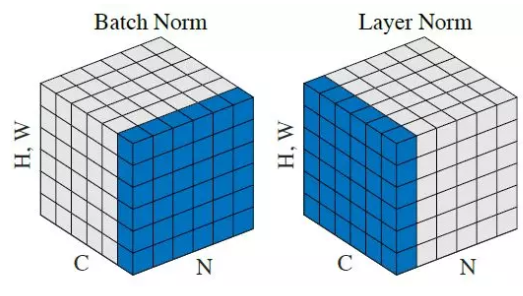

#### 3.1 Реализуйте Layer Normalization **(1 балл)**

In [26]:
# полезные функции: .std(dim), .mean(dim)

class LayerNormalization(nn.Module):
    def __init__(self, eps=1e-5):
        super(LayerNormalization, self).__init__()
        self.eps = eps
        
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True, unbiased=False)
        output = (x - mean) / (std + 1e-5)
        return output
        

#### 3.2 Сравните графики обучения нейроных сетей **(1 балл)**:
1. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Batch normalization между всеми слоями
2. Свертки из TestNetwork -> 128 -> 128 -> 10 с ReLU и Layer normalization между всеми слоями

In [27]:
layers_batchnorm = [
    nn.Linear(196, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 10)
]

network_batchnorm = TestNetwork(nn.Sequential(*layers_batchnorm))

layers_layernorm = [
    nn.Linear(196, 128),
    LayerNormalization(),
    nn.ReLU(),
    nn.Linear(128, 128),
    LayerNormalization(),
    nn.ReLU(),
    nn.Linear(128, 10)
]

network_layernorm = TestNetwork(nn.Sequential(*layers_layernorm))

## Обучение модели с BatchNorm

In [28]:
results_batchnorm = train_model(network_batchnorm, "BatchNorm")

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.366938
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.211434
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.108656
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.079966
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.132264
BatchNorm Epoch 0: Train Loss: 0.2411, Train Acc: 0.9383, Test Loss: 0.0988, Test Acc: 0.9682
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.072815
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.087867
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.126777
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.058476
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.061718
BatchNorm Epoch 1: Train Loss: 0.0789, Train Acc: 0.9748, Test Loss: 0.0712, Test Acc: 0.9771
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.061036
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.026463
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.048022
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.039157
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.056722
BatchNorm Epoch 2: Train Loss: 0.0569, Train Acc: 0.9818, Test Loss: 0.0591, 

## Обучение модели с LayerNorm

In [29]:
results_layernorm = train_model(network_layernorm, "LayerNorm")

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.279937
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.362496
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.201659
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.210542
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.248758
LayerNorm Epoch 0: Train Loss: 0.3830, Train Acc: 0.8902, Test Loss: 0.1637, Test Acc: 0.9491
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.261475
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.144736
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.051687
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.073568
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.074456
LayerNorm Epoch 1: Train Loss: 0.1205, Train Acc: 0.9619, Test Loss: 0.1051, Test Acc: 0.9652
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.077744
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.077738
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.064276
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.055428
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.033095
LayerNorm Epoch 2: Train Loss: 0.0848, Train Acc: 0.9731, Test Loss: 0.0966, 

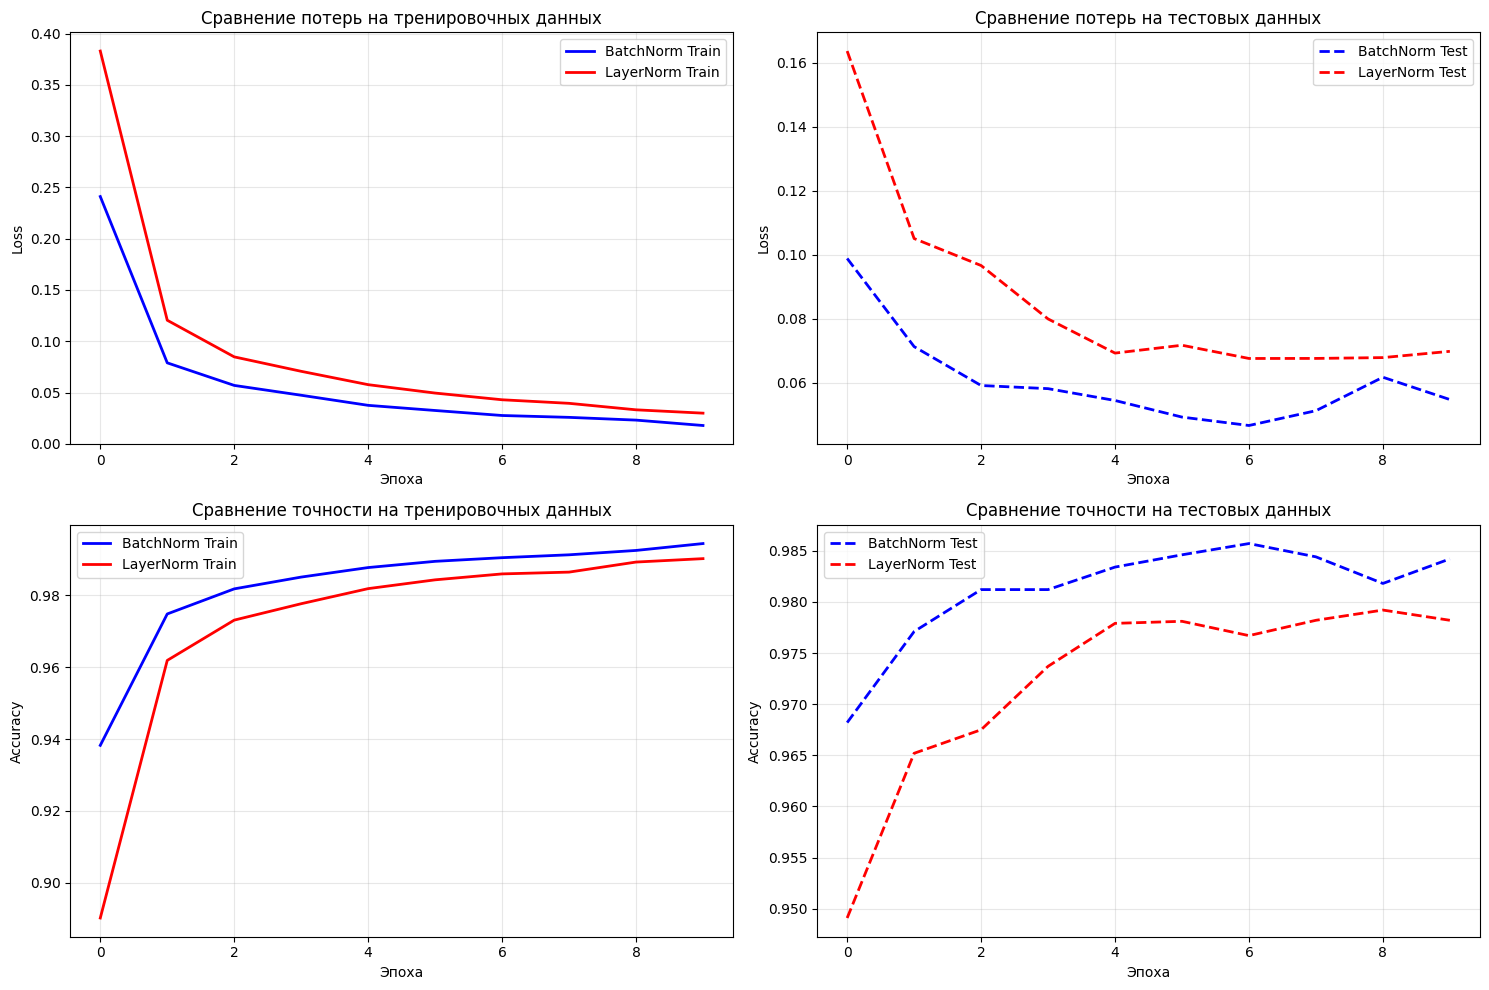

In [30]:
plt.figure(figsize=(15, 10))

# Графики потерь
plt.subplot(2, 2, 1)
plt.plot(results_batchnorm['train_losses'], 'b-', label='BatchNorm Train', linewidth=2)
plt.plot(results_layernorm['train_losses'], 'r-', label='LayerNorm Train', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сравнение потерь на тренировочных данных')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(results_batchnorm['test_losses'], 'b--', label='BatchNorm Test', linewidth=2)
plt.plot(results_layernorm['test_losses'], 'r--', label='LayerNorm Test', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Сравнение потерь на тестовых данных')
plt.legend()
plt.grid(True, alpha=0.3)

# Графики точности
plt.subplot(2, 2, 3)
plt.plot(results_batchnorm['train_accuracies'], 'b-', label='BatchNorm Train', linewidth=2)
plt.plot(results_layernorm['train_accuracies'], 'r-', label='LayerNorm Train', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Сравнение точности на тренировочных данных')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(results_batchnorm['test_accuracies'], 'b--', label='BatchNorm Test', linewidth=2)
plt.plot(results_layernorm['test_accuracies'], 'r--', label='LayerNorm Test', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.title('Сравнение точности на тестовых данных')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

У BatchNorm меньшие потери и более высокая точность.